In [1]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
from more_itertools import consecutive_groups
import csv
import glob, os
import string
import gsw
import seaborn as sns
import cartopy
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from netCDF4 import Dataset as netcdf_dataset
import cartopy.crs as ccrs   
import cmocean


In [2]:
#SET THE DIRECTORY WHERE THE FILES ARE
path = '/Users/hjb62/Python/Teaching/EOAS Teaching/EOSC473:573 Teaching/BamfieldCTD2025/all/'#Wed19Feb/'

filetype = 'aml'

#grab time from the file name:
def grab_time(x):
    return(x[-12:-4])

#import the list of files and sort them
file_list = glob.glob(os.path.join(path, f'*.{filetype}'))
file_list = sorted(file_list, key = grab_time) 
samp_longs=[None]*len(file_list)
samp_lats=[None]*len(file_list)

print(file_list)

['/Users/hjb62/Python/Teaching/EOAS Teaching/EOSC473:573 Teaching/BamfieldCTD2025/all/aml_log_2025-02-22_10-11-05.aml', '/Users/hjb62/Python/Teaching/EOAS Teaching/EOSC473:573 Teaching/BamfieldCTD2025/all/aml_log_2025-02-22_10-25-55.aml', '/Users/hjb62/Python/Teaching/EOAS Teaching/EOSC473:573 Teaching/BamfieldCTD2025/all/aml_log_2025-02-22_10-39-16.aml', '/Users/hjb62/Python/Teaching/EOAS Teaching/EOSC473:573 Teaching/BamfieldCTD2025/all/aml_log_2025-02-19_10-40-18.aml', '/Users/hjb62/Python/Teaching/EOAS Teaching/EOSC473:573 Teaching/BamfieldCTD2025/all/aml_log_2025-02-20_10-43-25.aml', '/Users/hjb62/Python/Teaching/EOAS Teaching/EOSC473:573 Teaching/BamfieldCTD2025/all/aml_log_2025-02-22_10-46-21.aml', '/Users/hjb62/Python/Teaching/EOAS Teaching/EOSC473:573 Teaching/BamfieldCTD2025/all/aml_log_2025-02-22_10-56-05.aml', '/Users/hjb62/Python/Teaching/EOAS Teaching/EOSC473:573 Teaching/BamfieldCTD2025/all/aml_log_2025-02-21_10-57-11.aml', '/Users/hjb62/Python/Teaching/EOAS Teaching/EOS

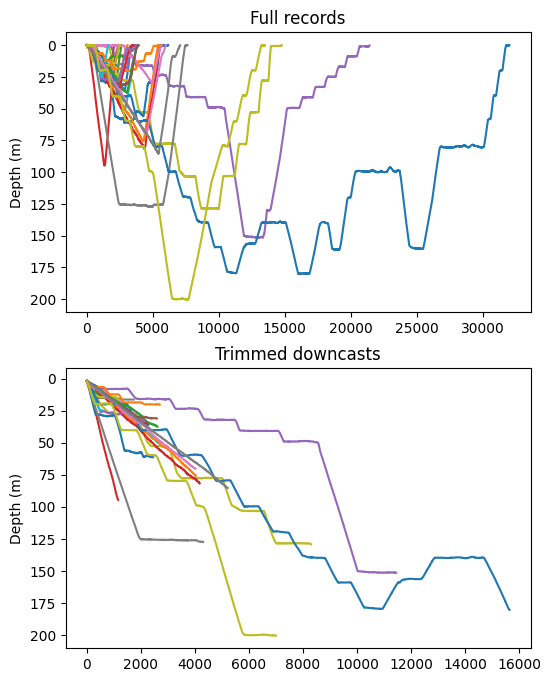

In [3]:
def conv_float(x):
    return float(x) if (x.replace('.', '', 1).isdigit() or x.lstrip('-').replace('.', '', 1).isdigit()) else float('nan')

def importfiles_v2(path, filetype, surface_threshold=2.0):
    """
    Improved version of importfiles.

    Key improvement — cast trimming:
    The original approach detects the end of soak using a gradient threshold on
    smoothed depth, then uses idxmin()/idxmax() as positional indices into iloc[].
    This has two problems:
      1. iloc[] vs loc[] mismatch: idxmin/idxmax return label-based indices, 
         which happen to work here because the DataFrame hasn't been reindexed, 
         but is a latent bug.
      2. The gradient threshold is sensitive to the smoothing window and cast 
         dynamics — noisy or slow descents can cause it to miss the soak period.

    The replacement approach uses 'last surface crossing':
      - Find the index of maximum depth (unambiguous bottom of cast).
      - In all data *before* that point, find the last row where depth is within
        `surface_threshold` metres of the surface. That is the end of the soak.
      - Slice using loc[] (label-based) throughout.

    This is more robust because it makes no assumptions about the rate of descent
    and requires no tuning of a gradient threshold. The only parameter is 
    `surface_threshold`, which has a physically intuitive meaning.
    """
    if filetype == 'aml':
        fig, axs = plt.subplots(nrows=2, figsize=(6, 8), sharex=False)
        axs[0].set_title('Full records')
        axs[1].set_title('Trimmed downcasts')
        dfs = list()
        samp_longs_v2 = [None] * len(file_list)
        samp_lats_v2 = [None] * len(file_list)

        for ind, fn in enumerate(file_list):
            nameline = np.nan
            header = np.nan
            with open(fn) as fh:
                for i, line in enumerate(fh):
                    if "MeasurementMetadata" in line:
                        nameline = i
                    elif "MeasurementData" in line:
                        header = i
                    elif i == nameline + 1:
                        line = line.strip()
                        cols = line.split("=", 1)[1].split(",")
                    elif "GPSLatitude" in line:
                        lat = line.split("=", 1)[1].strip()
                    elif "GPSLongitude" in line:
                        long = line.split("=", 1)[1].strip()

            samp_longs_v2[ind] = conv_float(long)
            samp_lats_v2[ind] = conv_float(lat)

            data = pd.read_csv(fn, header=header, names=cols)
            data['file'] = fn.split("log_")[-1].split("_")[-1].split(".")[0]
            data['profile'] = ind

            axs[0].plot(data['Depth'].values)

            # --- Improved trimming: last surface crossing ---
            maxdepth_idx = data['Depth'].idxmax()

            # Among all rows before the maximum depth, find the last row
            # where the instrument was still near the surface.
            pre_max = data.loc[:maxdepth_idx]
            near_surface = pre_max[pre_max['Depth'] < surface_threshold]

            cast_start = near_surface.index[-1] if len(near_surface) > 0 else pre_max.index[0]

            # Use loc[] throughout — label-safe, no iloc/label mismatch
            data = data.loc[cast_start:maxdepth_idx].copy()

            axs[1].plot(data['Depth'].values, label=ind)
            dfs.append(data)

        for ax in axs:
            ax.set_ylabel('Depth (m)')
            ax.invert_yaxis()

        df = pd.concat(dfs, ignore_index=True)
        return df, dfs, samp_longs_v2, samp_lats_v2

df_v2, dfs_v2, samp_longs_v2, samp_lats_v2 = importfiles_v2(path, filetype)

In [4]:
def conv_float(x): 
    return float(x) if (x.replace('.', '', 1).isdigit() or x.lstrip('-').replace('.', '', 1).isdigit()) else float('nan')

def importfiles(path,filetype):
    if filetype == 'cnv':
        header = 20
        dfs = list()
        for ind, fn in enumerate(file_list):
            cols = []
            with open(fn,encoding='latin-1') as fh:
                for i,line in enumerate(fh):
                    if "name" in line:
                        cols.append(line.split(" = ",1)[1].split(":")[0].strip())

            data = pd.read_csv(fn,encoding='latin-1',header=header,names=cols)#,sep='\s+')
            data['file'] = fn.split("_00")[1].split(".")[0]
            data_down = data[np.gradient(data['Depth [m]'].rolling(50).mean())>0.016]
            counter = 0
            data['profile'] = None
            for i in consecutive_groups(data_down.index):
                inds = list(i)
                if max(data.loc[inds,'Depth [m]']) > 5:
                    file = data.loc[inds,'file'].unique()[0]
                    data.loc[inds,'profile'] = f'{file+string.ascii_lowercase[counter]}'
                    counter = counter + 1
                else:
                    data.loc[inds,'profile'] = None
            data = data.dropna()
            dfs.append(data)
        df = pd.concat(dfs, ignore_index=True)
        df = df.drop('file',axis=1)
        print(df)

    elif filetype == 'txt':
        dfs = list()
        for ind, fn in enumerate(file_list):
            cols = []
            data = pd.read_csv(fn)
            data['file'] = fn.split("00")[-1].split(".")[0]
            data_down = data[np.gradient(data['Depth'].rolling(50).mean())>0.016]
            counter = 0
            for i in consecutive_groups(data_down.index):
                inds = list(i)
                if max(data.loc[inds,'Depth']) > 5:
                    file = data.loc[inds,'file'].unique()[0]
                    data.loc[inds,'profile'] = f'{file+string.ascii_lowercase[counter]}'
                    counter = counter + 1
                else:
                    data.loc[inds,'profile'] = np.nan
            data = data.dropna()
            dfs.append(data)
            print(dfs)
        df = pd.concat(dfs, ignore_index=True)
        df = df.drop('file',axis=1)
        print(df)

    elif filetype == 'aml':
        fig,axs = plt.subplots(nrows=3,figsize=(6,12),sharex=True)
        dfs = list()
        for ind, fn in enumerate(file_list):
            nameline = np.nan
            header = np.nan
            with open(fn) as fh:
                for i,line in enumerate(fh):
                    if "MeasurementMetadata" in line:
                        nameline = i
                    elif "MeasurementData" in line:
                        header = i
                    elif i == nameline + 1:
                        line = line.strip()
                        cols = line.split("=",1)[1].split(",")
                    elif "GPSLatitude" in line:
                        lat = line.split("=",1)[1].strip()
                    elif "GPSLongitude" in line:
                        long = line.split("=",1)[1].strip()
            samp_longs[ind]=conv_float(long)
            samp_lats[ind]=conv_float(lat)
            data = pd.read_csv(fn,header=header,names=cols)
            data['file'] = fn.split("log_")[-1].split("_")[-1].split(".")[0]
            data['profile']=0
            gradient = np.gradient(data['Depth'].rolling(100).mean())
            axs[0].plot(data['Depth'],label=data['file'][0])
            axs[0].legend()
            axs[1].plot(gradient)
            axs[0].grid(color='k',linestyle='--',linewidth=0.5)
            axs[1].grid(color='k',linestyle='--',linewidth=0.5)
            data_down = data[np.gradient(data['Depth'].rolling(100).mean())>0.015]
            endsoak = data.loc[gradient > 0.01]['Depth'].idxmin()
            maxdepth = data['Depth'].idxmax()
            data = data.iloc[endsoak:maxdepth].copy()
            data['profile']=ind
            axs[2].plot(data['Depth'],label=ind)
            # for i in consecutive_groups(data_down.index):
            #     inds = list(i)
            #     if max(data.loc[inds,'Depth']) > 5:
            #         file = data.loc[inds,'file'].unique()[0]
            #         data.loc[inds,'profile'] = f'{file+string.ascii_lowercase[counter]}'
            #         counter = counter + 1
            #     else:
            #         data.loc[inds,'file'] = np.nan
            # data = data.dropna()
            dfs.append(data)
        df = pd.concat(dfs, ignore_index=True)
#         df = df.drop('file',axis=1)
#         axs[1].set_ylim(0.016,0.04)
#         print(df)
    return df, dfs, samp_longs, samp_lats


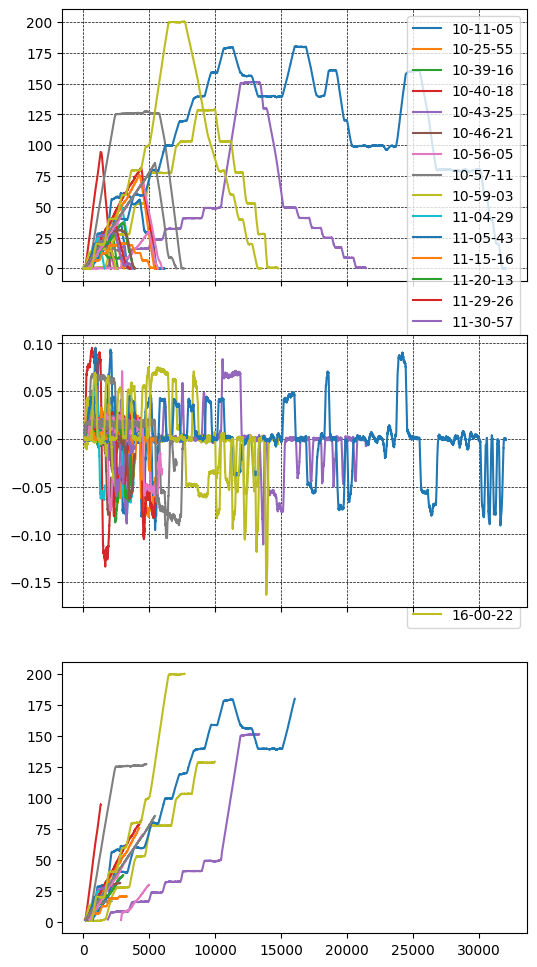

In [5]:
df, dfs, samp_longs, samp_lats = importfiles(path,filetype)


In [51]:
print(samp_longs,samp_lats)

[-125.18383, -125.18389, -125.17382, -125.14858, nan, -125.17577, -125.16484, -125.11559, -125.11234, -125.16085, -125.13601, -125.15752, -125.11478, -125.15197, -125.13744, -125.11601, -125.11169, -125.11145, -125.11988, -125.1152, -125.04865, -125.11478, -125.18845, -125.1827, -125.17481, -125.16426, -125.15707, -125.15279, -125.05043] [48.86092, 48.86116, 48.85899, 48.8519, nan, 48.86039, 48.86037, 48.85487, 48.87457, 48.86145, 48.84672, 48.86204, 48.85544, 48.86298, 48.83865, 48.85634, 48.87465, 48.87414, 48.85785, 48.85593, 48.89777, 48.85635, 48.85622, 48.85865, 48.85905, 48.86056, 48.86111, 48.86416, 48.89729]


In [52]:
# dfs_split=[]
# dfs_split.append(dfs[0].iloc[150:1300].copy())
# dfs_split.append(dfs[1].iloc[700:2900].copy())
# # dfs_split.append(dfs[2].iloc[550:1100].copy())
# for i,df in enumerate(dfs_split):
#     dfs_split[i]['profile']=i
# # subset = dfs[0].iloc[1180:1700].copy()
# plt.plot(dfs_split[0]['Pressure'])
# plt.plot(dfs_split[1]['Pressure'])
# # plt.plot(dfs_split[2]['Pressure'])
# df = pd.concat(dfs_split,ignore_index=True)

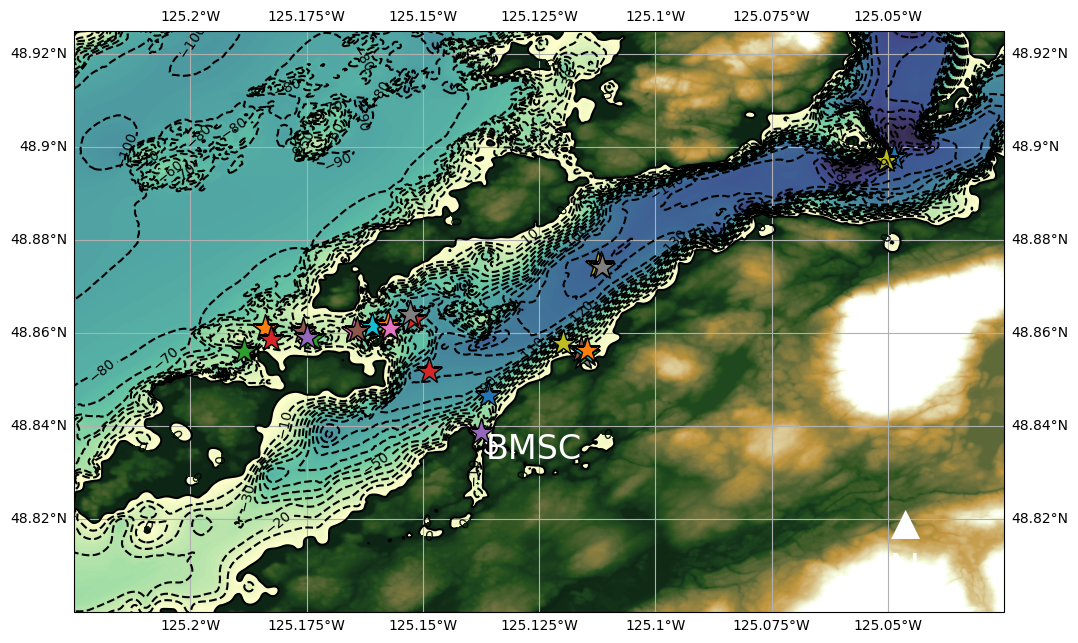

In [60]:
#Load Dataset
dataset = netcdf_dataset('barkley_sound_1_navd88_2016.nc')
depth = dataset.variables['Band1'][:, :]
lats = dataset.variables['lat'][:]
lons = dataset.variables['lon'][:]

map_projection = ccrs.PlateCarree()

fig,ax0=plt.subplots(figsize=(12, 12),subplot_kw={'projection': map_projection})

ax0.set_extent([-125.225,-125.025,48.8,48.925])


#Set ticks
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax0.xaxis.set_major_formatter(lon_formatter)
ax0.yaxis.set_major_formatter(lat_formatter)
ax0.gridlines(draw_labels=True)

#Plot BMSC
BMSC_lat=48.8355
BMSC_long=-125.1355
ax0.scatter(BMSC_long,BMSC_lat,s=140,color='k',transform=ccrs.PlateCarree(),zorder=2)
ax0.scatter(BMSC_long,BMSC_lat,s=90,color='white',transform=ccrs.PlateCarree(),zorder=2)
ax0.scatter(BMSC_long,BMSC_lat,s=40,color='k',transform=ccrs.PlateCarree(),zorder=2)
ax0.text(BMSC_long-0.001,BMSC_lat-0.0025,'BMSC',c='white',fontsize=24,transform=ccrs.PlateCarree())

#North Arrow
ax0.text(0.9, 0.05,u'\u25B2 \nN ', ha='center', color='white', fontsize=30, family='Arial',transform=ax0.transAxes)

CS1=ax0.contourf(lons, lats, depth, levels = np.linspace(-220,220,441), cmap=cmocean.cm.topo,transform=ccrs.PlateCarree(),zorder=1)
CS2=ax0.contour(lons, lats, depth, levels = np.linspace(-220,0,23), colors = 'black', transform=ccrs.PlateCarree(),zorder=2)
ax0.clabel(CS2,CS2.levels)

sns.color_palette("Spectral", n_colors=30)
for i in range(len(samp_longs)):
    ax0.plot(samp_longs[i],samp_lats[i],'*',markersize=20,markeredgecolor='k',transform=ccrs.PlateCarree())


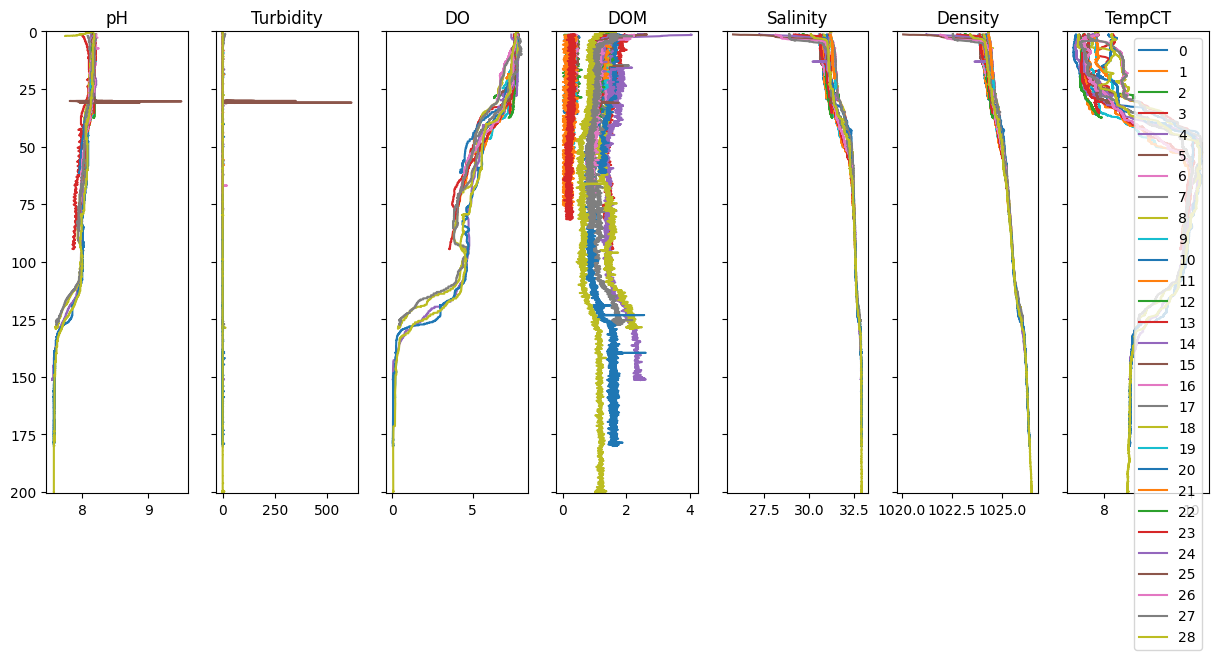

In [93]:
if filetype == 'cnv':
    data = df.drop(['CalcSV [m/s]','Pressure [dBar]','TempDO [C]'],axis=1)
    fig, axs = plt.subplots(ncols=len(data.keys())-2, figsize=(24,6),sharey=True)
    for ind, CTD in data.groupby('profile'):
        for i, key in enumerate(CTD.keys()):
            if key in ['Depth [m]','profile']:
                continue
            else:
                axs[i-1].set_ylim(max(data['Depth [m]'])+0.5,0)
                axs[i-1].plot(key,'Depth [m]',data=CTD,label=ind)
                axs[i-1].set_title(key)
                axs[i-1].legend()
elif filetype == 'txt':
    data = dfs.drop(['Date','Time','Pressure'],axis=1)
    fig, axs = plt.subplots(ncols=len(data.keys())-2, figsize=(15,6),sharey=True)
    for ind, CTD in data.groupby('file'):
        for i, key in enumerate(CTD.keys()):
            if key == 'Depth' or key == 'file':
                continue
            else:
                axs[i-1].set_ylim(max(data['Depth'])+0.5,0)
                axs[i-1].plot(key,'Depth',data=CTD,label=ind)
                axs[i-1].set_title(key)
                axs[i-1].legend()
elif filetype == 'aml':
    data = df.drop(['Date','Time','Pressure','file','CalcSV','Cond','TempDO'],axis=1)
    fig, axs = plt.subplots(ncols=len(data.keys())-2, figsize=(15,6),sharey=True)
    for ind, CTD in data.groupby('profile'):
        for i, key in enumerate(CTD.keys()):
            if key in ['Depth','profile']:
                continue
            elif key == 'DO':
                axs[i-1].set_ylim(max(data['Depth'])+0.5,0)
                axs[i-1].plot(CTD['DO']/43.57,CTD['Depth'],label=ind)
                axs[i-1].set_title(key)
            else:
                axs[i-1].set_ylim(max(data['Depth'])+0.5,0)
                axs[i-1].plot(key,'Depth',data=CTD,label=ind)
                axs[i-1].set_title(key)
                # axs[i-1].legend()
axs[6].legend()
# plt.savefig('LG_August_CTD.png',dpi=300,bbox_inches='tight')

0 8.17
1 8.19
2 8.2
3 8.18
4 8.17
5 8.2
6 8.2
7 8.16
8 8.17
9 8.2
10 8.17
11 8.2
12 8.16
13 8.2
14 8.17
15 8.17
16 8.25
17 8.2
18 8.17
19 8.19
20 8.2
21 8.19
22 8.19
23 8.18
24 8.21
26 8.21
27 8.2
28 8.18


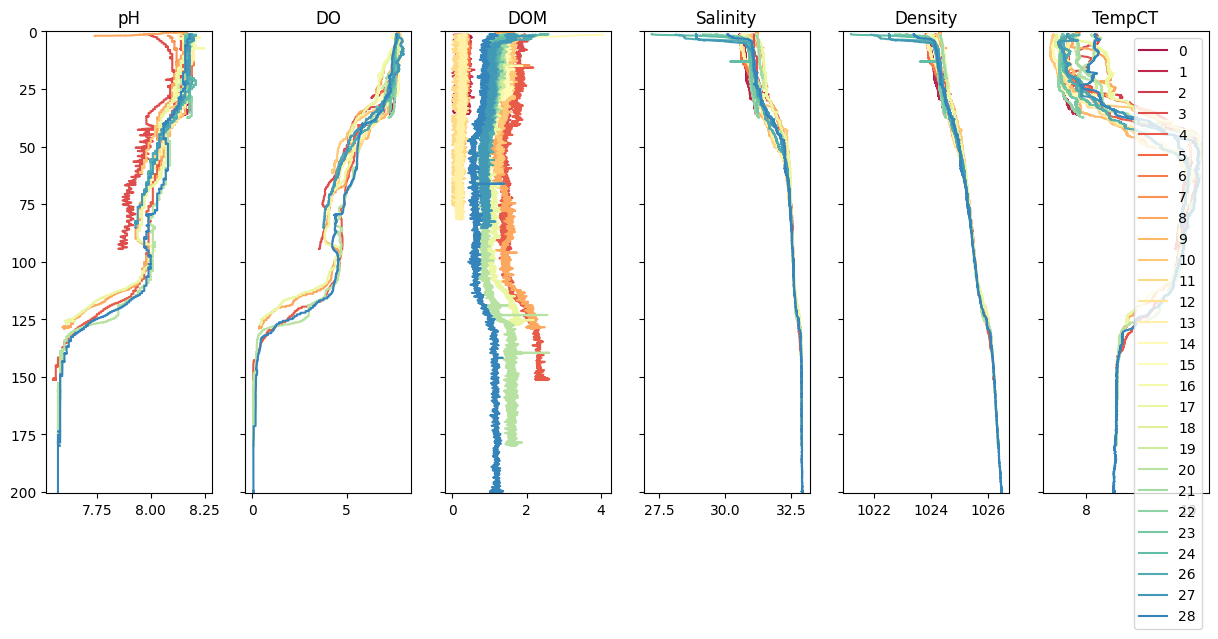

In [98]:
data = df.drop(['Date','Time','Pressure','file','CalcSV','Cond','TempDO','Turbidity'],axis=1)

with sns.color_palette("Spectral", n_colors=30):
    fig, axs = plt.subplots(ncols=len(data.keys())-2, figsize=(15,6),sharey=True)
    for ind, CTD in data.groupby('profile'):
        if ind == 25:
            continue
        else:
            for i, key in enumerate(CTD.keys()):
                if key in ['Depth','profile']:
                    continue
                elif key == 'DO':
                    axs[i-1].set_ylim(max(data['Depth'])+0.5,0)
                    axs[i-1].plot(CTD['DO']/43.57,CTD['Depth'],label=ind)
                    axs[i-1].set_title(key)
                else:
                    axs[i-1].set_ylim(max(data['Depth'])+0.5,0)
                    axs[i-1].plot(key,'Depth',data=CTD,label=ind)
                    axs[i-1].set_title(key)
            print(ind,max(CTD['pH']))
                # axs[i-1].legend()
    axs[5].legend()
    # axs[1].set_xlim(-0.05,0.75)


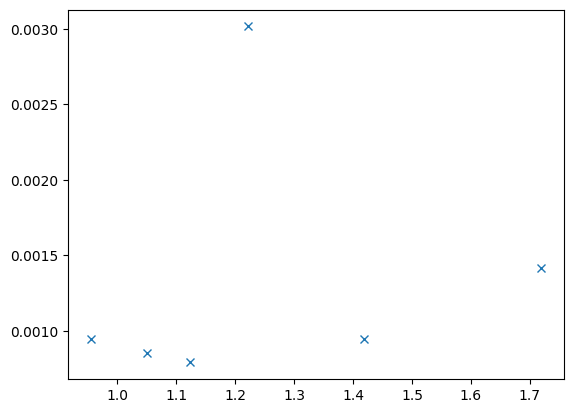

In [238]:
cdom_samp=[]
for x in [0,25,50,75,100,125]:
    cdom_samp.append(np.mean(dfs[0]['DOM'][(dfs[0]['Depth'] > x-3) & (dfs[0]['Depth'] < x+3)]))
cdom_spec = [0.00094378, 0.00301648, 0.00094378, 0.00079025, 0.00085346, 0.00141341]

plt.plot(cdom_samp,cdom_spec,'x')

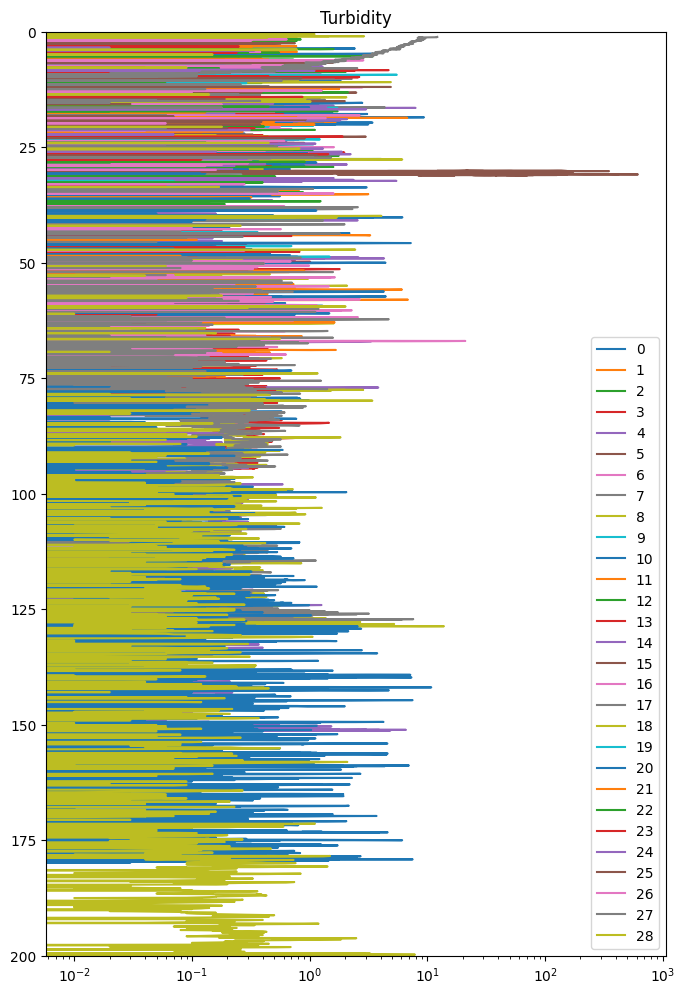

In [13]:
if filetype == 'aml':
#     data = df.drop(['scan','nbin','flag','sbeox0V','c0mS/cm'],axis=1)
    fig, ax0 = plt.subplots(ncols=1, figsize=(8,12),sharey=True)
    for ind, CTD in df.groupby('profile'):
        for i, key in enumerate(CTD.keys()):
            if key == 'Depth' or key == 'file':
                continue
            if key == 'Turbidity':
                ax0.plot(key,'Depth',data=CTD,label=ind)
                ax0.set_title(key)
                ax0.legend()
ax0.set_ylim(200,0)
# ax0.set_xlim(0,2)
ax0.set_xscale('log')

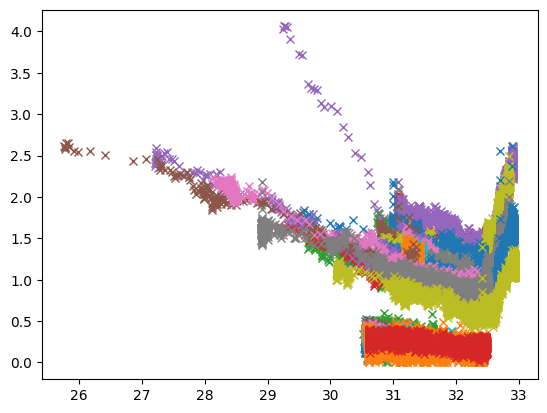

In [120]:
for ind, CTD in data.groupby('profile'):
    plt.plot(CTD['Salinity'],CTD['DOM'],'x',label=ind)
    # plt.legend()

5.74605 11.2783


Text(0, 0.5, 'Temperature (C)')

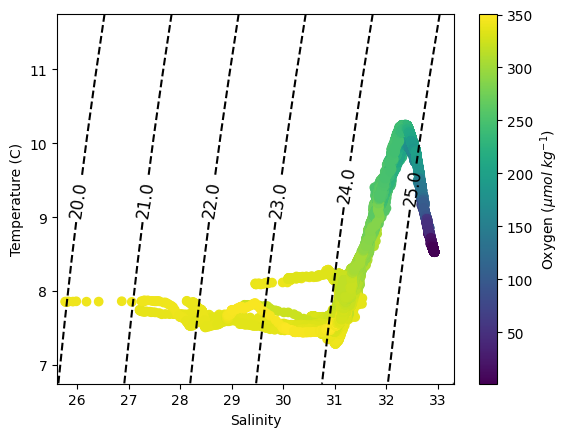

In [12]:
# Create variables with user-friendly names
temp  = df['TempCT']
salinity  = df['Salinity']
depth = df['Depth']
oxygen = df['DO']/43.57
DOM = df['DOM']

# Figure out boudaries (mins and maxs)
smin = salinity.min() - (0.01 * salinity.min())
smax = salinity.max() + (0.01 * salinity.max())
tmin = temp.min() - (0.15 * temp.max())
tmax = temp.max() + (0.1 * temp.max())

print(tmin,tmax)

# Calculate how many gridcells we need in the x and y dimensions
xdim = int(round((smax-smin)/0.1+1,0))
ydim = int(round((tmax-tmin)+1,0))

# Create empty grid of zeros
dens = np.zeros((ydim,xdim))

# Create temp and salinity vectors of appropiate dimensions
ti = np.linspace(1,ydim-1,ydim)+tmin
si = np.linspace(1,xdim-1,xdim)*0.1+smin

# Loop to fill in grid with densities
for j in range(0,int(ydim)):
    for i in range(0, int(xdim)):
        dens[j,i]=gsw.rho(si[i],ti[j],0)

# Substract 1000 to convert to sigma-t
dens = dens - 1000

# Plot data ***********************************************
fig, ax0 = plt.subplots()
CS = plt.contour(si,ti,dens, linestyles='dashed', colors='k')
plt.clabel(CS, fontsize=12, inline=1, fmt='%1.1f') # Label every second level

c=ax0.scatter(salinity,temp,c=df['DO'])


plt.colorbar(c,label='Oxygen ($\\mu mol$ $kg^{-1}$)')

ax0.set_xlabel('Salinity')
ax0.set_ylabel('Temperature (C)')


In [269]:
df.to_csv('Tue18CTD.csv')